In [1]:
# Objective :- Transform Numerical Column To Categorical (Binning Technique)
# -> Helps to improve Data distribution to Gaussian 
# Very Problem Specific

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('../../../DataBox/titanic_prepsd.csv',usecols=['Age','Fare','Survived'])
df.dropna(inplace=True)

In [3]:
# I/O and TTS
X = df.iloc[:,1:]
y = df.iloc[:,0]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
# Without Applying any transformation on numerical column

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

print(accuracy_score(y_test,y_pred))
print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

0.6223776223776224
0.6275234741784037


In [5]:
# Applying Binning (quantile strategy)

kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile', quantile_method='linear')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile', quantile_method='linear')

trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

output['age_labels'] = pd.cut(x=X_train['Age'], bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'], bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [6]:
# See how Binning has transformed

output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
606,30.0,8.0,7.8958,3.0,"(28.0, 30.0]","(7.775, 7.896]"
429,32.0,9.0,8.0500,3.0,"(30.0, 32.0]","(7.896, 8.158]"
134,25.0,6.0,13.0000,6.0,"(23.0, 25.0]","(10.5, 13.0]"
874,28.0,7.0,24.0000,8.0,"(25.0, 28.0]","(18.75, 26.0]"
843,34.5,9.0,6.4375,0.0,"(32.0, 35.0]","(0.0, 7.25]"


In [7]:
# Apply Model And verify

clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

print(accuracy_score(y_test,y_pred2))

X_trf = trf.fit_transform(X)
print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

0.6363636363636364
0.6275234741784038


In [8]:
# Generated a function to test any stratgies

def discretize(bins,strategy):
    
    # Can use different strategy for two different column
    
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6261150234741784


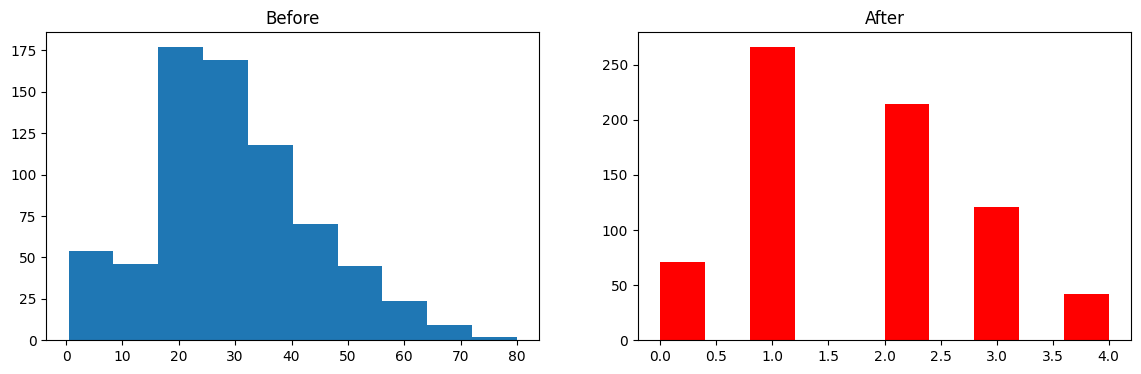

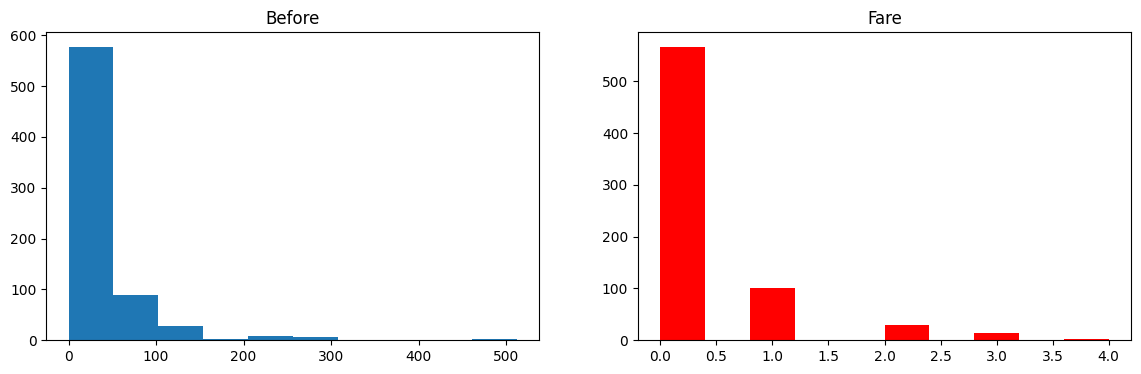

0.6302621283255085


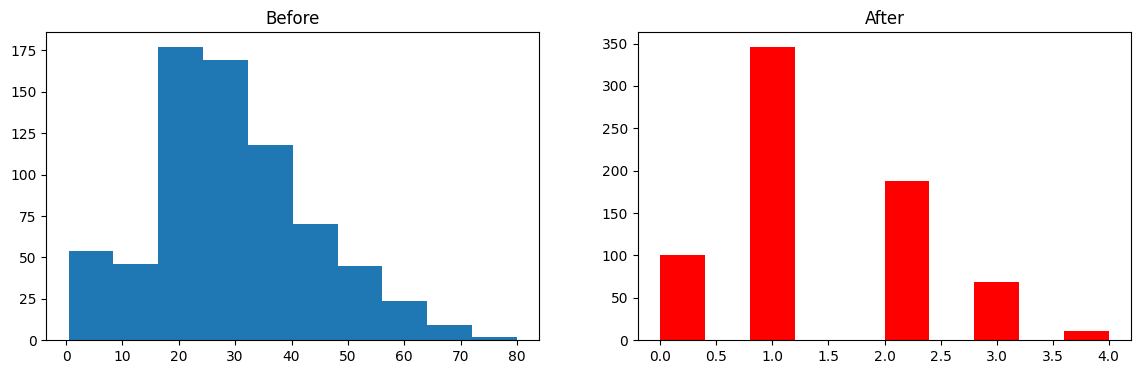

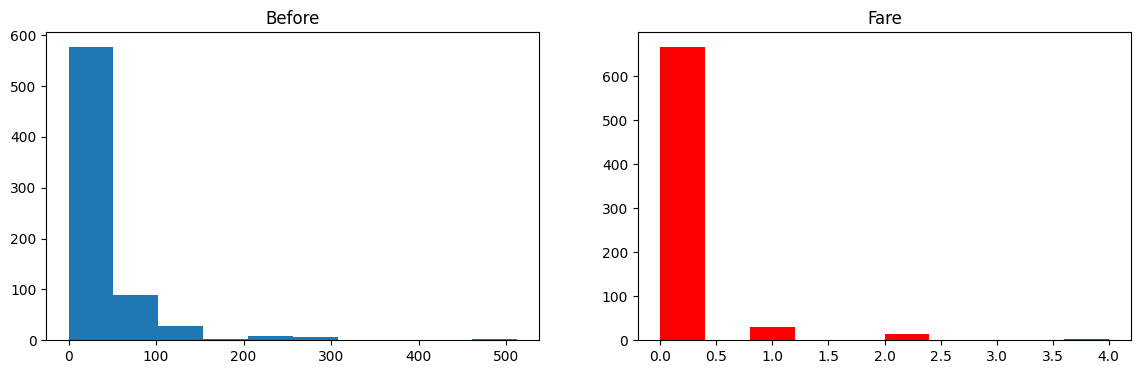

In [ ]:
discretize(5,'kmeans') # Number of bins and strategy
discretize(5,'uniform')

# For custom we need to write our own logic and implement via Pandas
# -> If you have full domain knowledge -> Can Create Custom Bins easily